Total simulation days: 90
Example first 5 call records for one day: [(778.0, 1, 143), (778.0, 2, 242), (2851.0, 1, 131), (2851.0, 1, 37), (3629.0, 1, 60)]
Starting training for Robust Q-learning strategy...


Training Iterations: 100%|██████████| 1000/1000 [00:06<00:00, 144.09it/s]


Training complete. Sample Q-values:
State (1, 0, 1, 0): Q(wait)=-3151.11, Q(assign)=-10.00
State (0, 0, 1, 1): Q(wait)=0.00, Q(assign)=0.00
State (2, 0, 1, 0): Q(wait)=-3849.18, Q(assign)=-1428.72
State (3, 0, 1, 0): Q(wait)=-10826.02, Q(assign)=-3622.29
State (2, 0, 1, 1): Q(wait)=0.00, Q(assign)=0.00


Evaluating: 100%|██████████| 90/90 [00:00<00:00, 6102.48it/s]


FCFS average waiting time: 52.96 seconds
Robust Q-learning average waiting time: 106.38 seconds


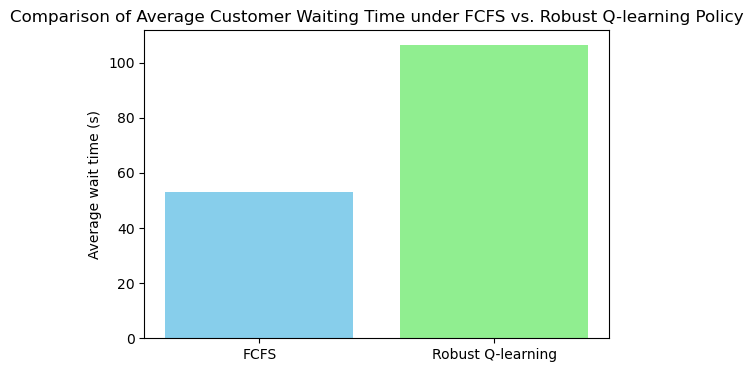

In [1]:
import pandas as pd
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from tqdm import tqdm   # for displaying progress bars
import heapq

# -----------------------
# 1. Data Loading and Preprocessing
# -----------------------
# Read the raw data (make sure Preprocessed_ModifiedCallCenterTwo.xlsx is in the current directory)
df = pd.read_excel("Preprocessed_ModifiedCallCenterTwo.xlsx")

# Classify calls by topic: assume "Technical Support" and "Streaming" are type2, others are type1
type2_topics = {"Technical Support", "Streaming"}
df["CallType"] = df["Topic"].apply(lambda x: 2 if x in type2_topics else 1)

# Convert time field: convert the "Time" column to datetime, then compute seconds elapsed since 09:00:00
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S")
start_of_day = pd.to_datetime("09:00:00", format="%H:%M:%S")
df["arrival_sec"] = (df["Time"] - start_of_day).dt.total_seconds()

# Filter calls within the 9 hours from 09:00 to 18:00 (i.e., 0 - 32400 seconds)
df = df[(df["arrival_sec"] >= 0) & (df["arrival_sec"] <= 32400)]

# Define a function to convert AvgTalkDuration from "HH:MM:SS" to seconds
def duration_to_seconds(dur):
    if isinstance(dur, str):
        h, m, s = map(int, dur.split(":"))
        return h * 3600 + m * 60 + s
    else:
        return 0

df["service_sec"] = df["AvgTalkDuration"].apply(duration_to_seconds)

# Group by date, with each day as a simulation episode
days_data = {}
for date, group in df.groupby("Date"):
    day_calls = group.sort_values("arrival_sec")
    # Each call record: (arrival_sec, CallType, service_sec)
    events = [(row["arrival_sec"], row["CallType"], row["service_sec"]) 
              for _, row in day_calls.iterrows()]
    if events:
        days_data[pd.to_datetime(date).date()] = events

print(f"Total simulation days: {len(days_data)}")
print(f"Example first 5 call records for one day: {list(days_data.values())[0][:5]}")

# -----------------------
# 2. Define the Simulation Environment Functions (FCFS and Robust Q-learning Strategies)
# -----------------------

def simulate_episode(events, policy="FCFS", Q_table=None, epsilon=0.0, M=50):
    """
    Simulate one day of call center operation
    events: List of events for the day, each element is (arrival_sec, call_type, service_sec)
    policy: "FCFS" or "RL"
    Q_table: If using the RL strategy, provide the Q-table dictionary
    epsilon: Exploration rate for epsilon-greedy (used only for the RL strategy)
    M: Maximum queue capacity
    Returns: total waiting time for the day, total number of calls served
    """
    # Queues: store type1 and type2 calls separately; each tuple is (arrival_time, service_time)
    q1 = []
    q2 = []
    # Server state: False indicates idle, True indicates busy
    b1_busy, b2_busy = False, False
    # Event heap: stores (finish_time, server, call_arrival_time)
    completions = []
    current_time = 0.0
    i = 0  # Index pointer for events

    total_wait = 0.0
    served = 0

    # Simulate events until the end of the work day (32400 seconds)
    while current_time < 32400:
        next_arrival = events[i][0] if i < len(events) else math.inf
        next_completion = completions[0][0] if completions else math.inf
        next_event = min(next_arrival, next_completion, 32400)
        # If next_event reaches the end-of-day, break to avoid popping from an empty heap
        if next_event == 32400:
            break
        current_time = next_event

        if current_time == next_arrival:
            # Arrival event
            arrival, call_type, svc_time = events[i]
            i += 1
            if call_type == 1:
                if not b1_busy:
                    # Server 1 idle, serve immediately
                    b1_busy = True
                    wait = 0.0
                    served += 1
                    finish = current_time + svc_time
                    heapq.heappush(completions, (finish, 1, current_time))
                elif not b2_busy:
                    # Server 1 busy, server 2 idle — decision point
                    if len(q1) + len(q2) < M:
                        q1.append((current_time, svc_time))
                        # Current state: number of waiting type1 and type2 calls and server statuses
                        state = (len(q1), len(q2), 1 if b1_busy else 0, 1 if b2_busy else 0)
                        if policy == "FCFS":
                            action = 1  # FCFS always serves immediately
                        elif policy == "RL" and Q_table is not None:
                            if random.random() < epsilon:
                                action = random.choice([0, 1])
                            else:
                                q_vals = Q_table.get(state, [0.0, 0.0])
                                action = int(np.argmax(q_vals))
                        else:
                            action = 1
                        if action == 1:
                            # Choose immediate service: remove from the queue
                            arr_time, svc_time_actual = q1.pop(0)
                            b2_busy = True
                            wait = current_time - arr_time
                            served += 1
                            total_wait += wait
                            finish = current_time + svc_time_actual
                            heapq.heappush(completions, (finish, 2, arr_time))
                        # If action is to wait, then keep the call in the queue
                    # If the queue is full, drop the call
                else:
                    # Both servers are busy
                    if len(q1) + len(q2) < M:
                        q1.append((current_time, svc_time))
            else:
                # Type2 call
                if not b2_busy:
                    b2_busy = True
                    wait = 0.0
                    served += 1
                    finish = current_time + svc_time
                    heapq.heappush(completions, (finish, 2, current_time))
                else:
                    if len(q1) + len(q2) < M:
                        q2.append((current_time, svc_time))
        else:
            # Completion event
            if completions:
                finish, server, call_arrival = heapq.heappop(completions)
            else:
                break
            if server == 1:
                b1_busy = False
            else:
                b2_busy = False
            # Assign waiting calls from the queue
            if not b1_busy and q1:
                arr_time, svc_time = q1.pop(0)
                b1_busy = True
                wait = current_time - arr_time
                served += 1
                total_wait += wait
                finish_new = current_time + svc_time
                heapq.heappush(completions, (finish_new, 1, arr_time))
            if not b2_busy:
                if q2:
                    arr_time, svc_time = q2.pop(0)
                    b2_busy = True
                    wait = current_time - arr_time
                    served += 1
                    total_wait += wait
                    finish_new = current_time + svc_time
                    heapq.heappush(completions, (finish_new, 2, arr_time))
                elif q1:
                    # For type1 calls, when server 2 is idle, decide based on the policy
                    state = (len(q1), len(q2), 1 if b1_busy else 0, 0)
                    if policy == "FCFS":
                        action = 1
                    elif policy == "RL" and Q_table is not None:
                        if random.random() < epsilon:
                            action = random.choice([0, 1])
                        else:
                            q_vals = Q_table.get(state, [0.0, 0.0])
                            action = int(np.argmax(q_vals))
                    else:
                        action = 1
                    if action == 1:
                        arr_time, svc_time = q1.pop(0)
                        b2_busy = True
                        wait = current_time - arr_time
                        served += 1
                        total_wait += wait
                        finish_new = current_time + svc_time
                        heapq.heappush(completions, (finish_new, 2, arr_time))
                    # Otherwise, do nothing and continue waiting
    return total_wait, served

# -----------------------
# 3. Training Based on the Robust Q-learning Strategy
# -----------------------
Q = {}

def get_Q_values(state):
    if state not in Q:
        Q[state] = [0.0, 0.0]
    return Q[state]

episodes = list(days_data.keys())   # Each day as an episode
num_iterations = 1000               # Number of training iterations
gamma = 0.95                        # Discount factor
alpha0 = 0.5                        # Initial learning rate
epsilon0 = 0.1                      # Initial epsilon exploration rate
decay_rate = 0.99                   # Decay rate for learning rate and epsilon
penalty = 10.0                      # Robust penalty applied for immediate service action

print("Starting training for Robust Q-learning strategy...")
for it in tqdm(range(num_iterations), desc="Training Iterations"):
    for day in episodes:
        events = days_data[day]
        events = sorted(events, key=lambda x: x[0])
        # Initialize environment
        q1 = []
        q2 = []
        b1_busy, b2_busy = False, False
        completions = []
        current_time = 0.0
        i = 0
        last_decision_time = 0.0
        # During simulation, update Q-values at each decision point (only when server 2 is idle and a type1 call is waiting)
        while current_time < 32400:
            next_arrival = events[i][0] if i < len(events) else math.inf
            next_completion = completions[0][0] if completions else math.inf
            next_event = min(next_arrival, next_completion, 32400)
            if next_event == 32400:
                break
            current_time = next_event

            if current_time == next_arrival:
                arrival, call_type, svc_time = events[i]
                i += 1
                if call_type == 1:
                    if not b1_busy:
                        b1_busy = True
                        finish = current_time + svc_time
                        heapq.heappush(completions, (finish, 1, current_time))
                    elif not b2_busy:
                        if len(q1) + len(q2) < 50:
                            q1.append((current_time, svc_time))
                            state = (len(q1), len(q2), 1 if b1_busy else 0, 1 if b2_busy else 0)
                            if random.random() < epsilon0:
                                action = random.choice([0, 1])
                            else:
                                q_vals = get_Q_values(state)
                                action = int(np.argmax(q_vals))
                            if action == 1:
                                arr_time, svc_time_actual = q1.pop(0)
                                b2_busy = True
                                wait = current_time - arr_time
                                finish = current_time + svc_time_actual
                                heapq.heappush(completions, (finish, 2, arr_time))
                            reward = - (len(q1) + len(q2)) * (current_time - last_decision_time)
                            inst_reward = (- penalty) if action == 1 else 0.0
                            new_state = (len(q1), len(q2), 1 if b1_busy else 0, 1 if b2_busy else 0)
                            Q_vals = get_Q_values(state)
                            next_Q = get_Q_values(new_state)
                            target = (reward + inst_reward) + gamma * max(next_Q)
                            Q_vals[action] += alpha0 * (target - Q_vals[action])
                            Q[state] = Q_vals
                            last_decision_time = current_time
                    else:
                        if len(q1) + len(q2) < 50:
                            q1.append((current_time, svc_time))
                else:
                    if not b2_busy:
                        b2_busy = True
                        finish = current_time + svc_time
                        heapq.heappush(completions, (finish, 2, current_time))
                    else:
                        if len(q1) + len(q2) < 50:
                            q2.append((current_time, svc_time))
            else:
                finish, server, call_arrival = heapq.heappop(completions)
                if server == 1:
                    b1_busy = False
                else:
                    b2_busy = False
                if not b1_busy and q1:
                    arr_time, svc_time = q1.pop(0)
                    b1_busy = True
                    finish = current_time + svc_time
                    heapq.heappush(completions, (finish, 1, arr_time))
                if not b2_busy:
                    if q2:
                        arr_time, svc_time = q2.pop(0)
                        b2_busy = True
                        finish = current_time + svc_time
                        heapq.heappush(completions, (finish, 2, arr_time))
                    elif q1:
                        state = (len(q1), len(q2), 1 if b1_busy else 0, 0)
                        if random.random() < epsilon0:
                            action = random.choice([0, 1])
                        else:
                            q_vals = get_Q_values(state)
                            action = int(np.argmax(q_vals))
                        if action == 1:
                            arr_time, svc_time = q1.pop(0)
                            b2_busy = True
                            finish = current_time + svc_time
                            heapq.heappush(completions, (finish, 2, arr_time))
                        reward = - (len(q1) + len(q2)) * (current_time - last_decision_time)
                        inst_reward = (- penalty) if action == 1 else 0.0
                        new_state = (len(q1), len(q2), 1 if b1_busy else 0, 1 if b2_busy else 0)
                        Q_vals = get_Q_values(state)
                        next_Q = get_Q_values(new_state)
                        target = (reward + inst_reward) + gamma * max(next_Q)
                        Q_vals[action] += alpha0 * (target - Q_vals[action])
                        Q[state] = Q_vals
                        last_decision_time = current_time
        # Decay the learning rate and epsilon
    alpha0 *= decay_rate
    epsilon0 *= decay_rate

print("Training complete. Sample Q-values:")
for s, vals in list(Q.items())[:5]:
    print(f"State {s}: Q(wait)={vals[0]:.2f}, Q(assign)={vals[1]:.2f}")

policy_Q = {}
for state, q_vals in Q.items():
    policy_Q[state] = int(np.argmax(q_vals))

# -----------------------
# 4. Performance Evaluation and Visual Comparison
# -----------------------
total_wait_fcfs = 0.0
total_served_fcfs = 0
total_wait_rl = 0.0
total_served_rl = 0

for day in tqdm(list(days_data.keys()), desc="Evaluating"):
    events = days_data[day]
    wait_fcfs, served_fcfs = simulate_episode(events, policy="FCFS", M=50)
    total_wait_fcfs += wait_fcfs
    total_served_fcfs += served_fcfs
    wait_rl, served_rl_day = simulate_episode(events, policy="RL", Q_table=policy_Q, epsilon=0.0, M=50)
    total_wait_rl += wait_rl
    total_served_rl += served_rl_day

avg_wait_fcfs = total_wait_fcfs / total_served_fcfs if total_served_fcfs > 0 else 0
avg_wait_rl = total_wait_rl / total_served_rl if total_served_rl > 0 else 0

print(f"FCFS average waiting time: {avg_wait_fcfs:.2f} seconds")
print(f"Robust Q-learning average waiting time: {avg_wait_rl:.2f} seconds")

plt.figure(figsize=(6, 4))
policies = ["FCFS", "Robust Q-learning"]
avg_waits = [avg_wait_fcfs, avg_wait_rl]
colors = ["skyblue", "lightgreen"]
plt.bar(policies, avg_waits, color=colors)
plt.ylabel("Average wait time (s)")
plt.title("Comparison of Average Customer Waiting Time under FCFS vs. Robust Q-learning Policy")
plt.show()

# print(df)


Loaded 90 days  |  sample → 2021-01-01


/Users/mentha/anaconda3/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



=== PPO training started ===
=== PPO training finished ===



Eval-PPO: 100%|██████████| 90/90 [00:00<00:00, 481.11it/s]


PPO  - Avg wait = 94.21 s


Eval-FCFS: 100%|██████████| 90/90 [00:00<00:00, 31578.33it/s]

FCFS - Avg wait = 52.96 s   (queue=50)


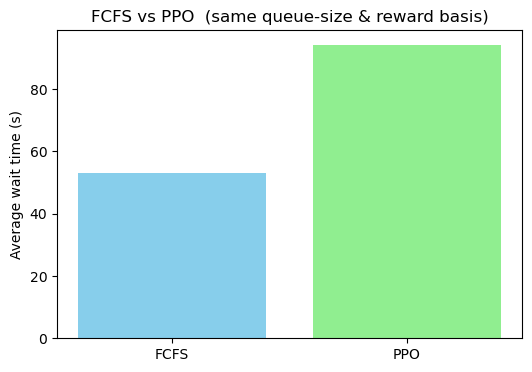

In [2]:
# =========================================
# Call-centre PPO vs FCFS   (Revised 2025-04-29)
# =========================================
import pandas as pd
import numpy as np
import math, random, heapq
import matplotlib.pyplot as plt
from tqdm import tqdm
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# ---------- 0. Global hyper-params ----------
MAX_QUEUE  = 50          # 与第 2 份脚本保持一致
PENALTY    = 2.0         # 等同于 Q-learning 脚本中的 penalty
WORK_END   = 32_400      # 09:00-18:00

# ---------- 1. Data loading / preprocessing ----------
df = pd.read_excel("Preprocessed_ModifiedCallCenterTwo.xlsx")

type2_topics = {"Technical Support", "Streaming"}
df["CallType"] = df["Topic"].apply(lambda x: 2 if x in type2_topics else 1)

df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S")
start_of_day = pd.to_datetime("09:00:00", format="%H:%M:%S")
df["arrival_sec"] = (df["Time"] - start_of_day).dt.total_seconds()
df = df[(df["arrival_sec"] >= 0) & (df["arrival_sec"] <= WORK_END)]

def duration_to_seconds(txt):
    if isinstance(txt, str):
        h, m, s = map(int, txt.split(":"))
        return h*3600 + m*60 + s
    return 0

df["service_sec"] = df["AvgTalkDuration"].apply(duration_to_seconds)

days_data = {}
for date, g in df.groupby("Date"):
    calls = [(row["arrival_sec"], row["CallType"], row["service_sec"])
             for _, row in g.sort_values("arrival_sec").iterrows()]
    if calls:
        days_data[pd.to_datetime(date).date()] = calls

print(f"Loaded {len(days_data)} days  |  sample → {list(days_data.keys())[0]}")

# ---------- 2. Custom Gym environment ----------
class CallCenterEnv(gym.Env):
    """
    Action: 0 = 等待 / 不把 Type-1 分给 Server-2
            1 = 把队首 Type-1 分给 Server-2
    Reward: 若 action=1 且成功分配，则 -wait - PENALTY
            其余情况 0
    """
    metadata = {"render.modes": []}

    def __init__(self, events, max_queue=MAX_QUEUE):
        super().__init__()
        self.events     = events
        self.max_queue  = max_queue
        self.action_space      = spaces.Discrete(2)
        # (len(q1), len(q2), b1_busy, b2_busy)
        self.observation_space = spaces.MultiDiscrete(
            [max_queue+1, max_queue+1, 2, 2]
        )
        self.reset()

    # ---- helpers ----
    def _state(self):
        return np.array(
            [len(self.q1), len(self.q2),
             int(self.b1_busy), int(self.b2_busy)],
            dtype=np.int32
        )

    # ---- core API ----
    def reset(self):
        self.q1, self.q2 = [], []
        self.b1_busy = self.b2_busy = False
        self.comp = []                 # completion heap
        self.t = 0.0
        self.i = 0                     # index in self.events
        self.total_wait = 0.0
        return self._state()

    def step(self, action):
        """Let the sim run until next ‘decision point’ or end-of-day."""
        reward = 0.0
        done = False

        while self.t < WORK_END:
            nxt_arr = self.events[self.i][0] if self.i < len(self.events) else math.inf
            nxt_cmp = self.comp[0][0]       if self.comp else math.inf
            nxt_evt = min(nxt_arr, nxt_cmp, WORK_END)
            if nxt_evt == WORK_END:
                done = True
                break
            self.t = nxt_evt

            # ----- arrival -----
            if self.t == nxt_arr:
                arr, typ, svc = self.events[self.i]
                self.i += 1
                if typ == 1:  # type-1
                    if not self.b1_busy:
                        self.b1_busy = True
                        heapq.heappush(self.comp, (self.t+svc, 1, arr))
                    elif not self.b2_busy:
                        # decision point ─ Server-2 idle
                        if action == 1:
                            # 服务立即开始，计算等待
                            wait = 0.0                # arrived just now
                            reward = -wait - PENALTY
                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t+svc, 2, arr))
                        else:
                            # 入队
                            if len(self.q1)+len(self.q2) < self.max_queue:
                                self.q1.append((arr, svc))
                        break  # 一个决策完成，退出 while 并返回
                    else:
                        if len(self.q1)+len(self.q2) < self.max_queue:
                            self.q1.append((arr, svc))
                else:         # type-2
                    if not self.b2_busy:
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t+svc, 2, arr))
                    else:
                        if len(self.q1)+len(self.q2) < self.max_queue:
                            self.q2.append((arr, svc))
            # ----- completion -----
            else:
                fin, srv, arr_time = heapq.heappop(self.comp)
                if srv == 1:
                    self.b1_busy = False
                else:
                    self.b2_busy = False
                # server-1 先拉队首 type-1
                if not self.b1_busy and self.q1:
                    a, s = self.q1.pop(0)
                    self.total_wait += self.t - a
                    self.b1_busy = True
                    heapq.heappush(self.comp, (self.t+s, 1, a))
                # server-2：先 type-2，再看是否需要决策
                if not self.b2_busy:
                    if self.q2:
                        a, s = self.q2.pop(0)
                        self.total_wait += self.t - a
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t+s, 2, a))
                    elif self.q1:
                        # 决策点：是否把队首 type-1 分给 server-2
                        if action == 1:
                            a, s = self.q1.pop(0)
                            wait = self.t - a
                            reward = -wait - PENALTY
                            self.total_wait += wait
                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t+s, 2, a))
                        # 无论 action 如何，都需返回给 PPO
                        break
        return self._state(), reward, done, {}

# ---------- 3. Create vectorised env & train PPO ----------
vec_env = DummyVecEnv([lambda ev=ev: CallCenterEnv(ev)
                       for ev in list(days_data.values())[:5]])

model = PPO("MlpPolicy", vec_env, verbose=0)
print("\n=== PPO training started ===")
model.learn(total_timesteps=100_000)
print("=== PPO training finished ===\n")

# ---------- 4. Evaluate PPO policy ----------
def run_policy(events, model):
    env = CallCenterEnv(events)
    obs = env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs)
        obs, _, done, _ = env.step(action)
    return env.total_wait, len(events)

tot_wait_ppo = tot_calls_ppo = 0
for d, ev in tqdm(days_data.items(), desc="Eval-PPO"):
    w, n = run_policy(ev, model)
    tot_wait_ppo  += w
    tot_calls_ppo += n
avg_wait_ppo = tot_wait_ppo / tot_calls_ppo
print(f"PPO  - Avg wait = {avg_wait_ppo:.2f} s")

# ---------- 5. FCFS baseline (same as script-2) ----------
def simulate_fcfs(events, max_queue=MAX_QUEUE):
    q1, q2 = [], []
    b1_busy = b2_busy = False
    comp = []
    time, i = 0.0, 0
    wait_sum = served = 0

    while time < WORK_END:
        nxt_arr = events[i][0] if i < len(events) else math.inf
        nxt_cmp = comp[0][0]    if comp else math.inf
        nxt_evt = min(nxt_arr, nxt_cmp, WORK_END)
        if nxt_evt == WORK_END:
            break
        time = nxt_evt

        # ----- arrival -----
        if time == nxt_arr:
            arr, typ, svc = events[i]
            i += 1
            if typ == 1:
                if not b1_busy:
                    b1_busy = True
                    heapq.heappush(comp, (time+svc, 1, arr))
                    served += 1
                elif not b2_busy:
                    b2_busy = True
                    heapq.heappush(comp, (time+svc, 2, arr))
                    served += 1
                elif len(q1)+len(q2) < max_queue:
                    q1.append((arr, svc))
            else:  # type-2
                if not b2_busy:
                    b2_busy = True
                    heapq.heappush(comp, (time+svc, 2, arr))
                    served += 1
                elif len(q1)+len(q2) < max_queue:
                    q2.append((arr, svc))
        # ----- completion -----
        else:
            fin, srv, arr_time = heapq.heappop(comp)
            if srv == 1:
                b1_busy = False
            else:
                b2_busy = False
            # server-1
            if not b1_busy and q1:
                a, s = q1.pop(0)
                wait_sum += time - a
                served += 1
                b1_busy = True
                heapq.heappush(comp, (time+s, 1, a))
            # server-2
            if not b2_busy:
                if q2:
                    a, s = q2.pop(0)
                    wait_sum += time - a
                    served += 1
                    b2_busy = True
                    heapq.heappush(comp, (time+s, 2, a))
                elif q1:
                    a, s = q1.pop(0)
                    wait_sum += time - a
                    served += 1
                    b2_busy = True
                    heapq.heappush(comp, (time+s, 2, a))
    return wait_sum, served

tot_wait_fcfs = tot_serv_fcfs = 0
for ev in tqdm(days_data.values(), desc="Eval-FCFS"):
    w, n = simulate_fcfs(ev)
    tot_wait_fcfs += w
    tot_serv_fcfs += n
avg_wait_fcfs = tot_wait_fcfs / tot_serv_fcfs
print(f"FCFS - Avg wait = {avg_wait_fcfs:.2f} s   (queue={MAX_QUEUE})")

# ---------- 6. Visual comparison ----------
plt.figure(figsize=(6,4))
plt.bar(["FCFS", "PPO"], [avg_wait_fcfs, avg_wait_ppo],
        color=["skyblue", "lightgreen"])
plt.ylabel("Average wait time (s)")
plt.title("FCFS vs PPO  (same queue-size & reward basis)")
plt.show()
